In [1]:
%load_ext autoreload
%autoreload 2

import os
os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"
assert os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] == "false"

import sys
sys.path.append('../')
sys.path.append('../../')


import ATLAS

import json, pickle
from glob import glob
from tqdm import tqdm

import numpy as np
from matplotlib import pyplot as plt

from functools import partial
import jax.numpy as jnp
import jax.random as jrandom

from ATLAS.utils import jit, jit_method, get_pulsar_timespan
from ATLAS.utils import jagged2padded
from ATLAS.signals.signals_utils import _timing_model_svd, get_fourier_design_matrix

import numpyro
import numpyro.distributions as dist

sim_path = '../../datasets/sim_NG15_01'
with open(sim_path+'/injected_params.json', 'r') as f:
    injected_params = json.load(f)

JAX 64-bit mode automatically enabled successfully.


/home/kyleg/miniforge3/envs/atlas/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
from ATLAS.pulsar import load_pulsars
from ATLAS.data import PTA_Data

npsrs = 2

par = sorted(glob(sim_path+'/par/*.par'))[10:10+npsrs]
tim = sorted(glob(sim_path+'/tim/*.tim'))[10:10+npsrs]

psrs = load_pulsars(par, tim, use_enterprise=True)

data = PTA_Data(psrs, fixed_res = False, marg_timing = False, 
                diag_white_cov = False, linear_timing = True)


libstempo not installed. PINT or libstempo are required to use par and tim files.
Loading pulsars...:   0%|          | 0/2 [00:00<?, ?it/s]

JAX 64-bit mode automatically enabled successfully.JAX 64-bit mode automatically enabled successfully.



libstempo not installed. PINT or libstempo are required to use par and tim files.
libstempo not installed. PINT or libstempo are required to use par and tim files.
Loading pulsars...: 100%|██████████| 2/2 [00:07<00:00,  3.77s/it]


## Timing model

Lets try taking out the binary columns, normalizing the non-binary columns, then stack back together

In [34]:
binary_priors = {
    'PB':       dist.Uniform(0.05, 500),        # Orbital period (days)
    'PBDOT':    dist.Uniform(-1e-10, 1e-10),    # Time derivative of orbital period
    'A1':       dist.Uniform(0, 150),           # Projected semi-major axis (light-seconds)
    'A1DOT':    dist.Uniform(-1e-10, 1e-10),    # Time derivative of A1
#    'T0':       None, # Use _DT0 to derive     # Epoch of periastron passage (MJD)
#    'TASC':     None, # Use _DTASC to derive   # Epoch of ascending node passage (MJD)
    'ECC':      dist.Uniform(0, 1),             # Orbital eccentricity
    'EDOT':     dist.Uniform(-1e-10, 0),        # Time derivative of eccentricity
    'OM':       dist.Uniform(-360, 360),        # Longitude of periastron (deg)
    'OMDOT':    dist.Uniform(-3, 3),            # Time derivative of OM
    'EPS1':     dist.Uniform(-1, 1),            # Laplace-Lagrange parameter e*sin(omega)
    'EPS2':     dist.Uniform(-1, 1),            # Laplace-Lagrange parameter e*cos(omega)
    'SINI':     None, # Use COSI to derive      # sin(inclination)
    'M2':       dist.TruncatedNormal(loc=0.214, scale=0.25, 
                low=0, high=1),                 # Companion mass (solar masses)
    'KIN':      dist.Uniform(0, 360),           # Inclination angle (deg), used by DDK
    'KOM':      dist.Uniform(-180, 180),        # Longitude of ascending node (deg), used by DDK
    'H3':       dist.Uniform(-1e-6, 1e-6),      # Orthometric Shapiro delay amplitude
    'FB0':      dist.Uniform(0, 1),             # Orbital frequency and derivatives (ELL1)
    'FB1':      dist.Uniform(-1e-15, 1e-15),     
    'FB2':      dist.Uniform(-1e-15, 1e-15),
    'FB3':      dist.Uniform(-1e-15, 1e-15),
    'FB4':      dist.Uniform(-1e-15, 1e-15),
    'FB5':      dist.Uniform(-1e-15, 1e-15),
}

class binary_tm:
    def __init__(self, psr):
        self.psr = psr
        self.name = psr.name
        self.residuals = psr.residuals
        
        self.M = psr.Mmat # (n_toas, npar)
        self.M_labels = psr.Mmat_labels # Labels of the columns in the M matrix (npar,)
        self.M_par = self.M.shape[1] # number of parameters in the M matrix

        # Fit parameter values and uncertainties with an added offset column
        self.hat = jnp.insert(psr.fit_param_values, 0, 0) # Add offset column (npar,)
        self.sigma = jnp.insert(psr.fit_param_uncertainties, 0, 1) # Add offset column (npar,)

        # Make boolean masks of binary and other parameters in the M matrix
        self.Mb_idx = jnp.array([label in binary_priors for label in self.M_labels])
        self.Mo_idx = ~self.Mb_idx

        self.Mb = self.M[:, self.Mb_idx] # Binary parameters in the M matrix
        self.Mb_labels = [label for label in self.M_labels if label in binary_priors] # Labels of the binary parameters in the M matrix
        self.Mb_par = self.Mb.shape[1] # number of binary parameters in the M matrix
        self.hat_b = self.hat[self.Mb_idx] # Fit parameter values for binary parameters
        self.sigma_b = self.sigma[self.Mb_idx] # Fit parameter uncertainties for binary parameters
        
        self.Mo = _timing_model_svd(self.M[:, self.Mo_idx]) # Other parameters in the M matrix (SVD'd)
        self.Mo_labels = [label for label in self.M_labels if label not in binary_priors] # Labels of the other parameters in the M matrix
        self.Mo_par = self.Mo.shape[1] # number of other parameters in the M matrix

    def sample_prior(self):
        theta_b = jnp.zeros(self.Mb_par) # Initialize binary parameter epsilons
        for i, label in enumerate(self.Mb_labels):
            # Most parameters have defined priors except for SINI
            if 'SINI' in label:
                # Sample in uniform COSI instead
                cosi_dist = dist.Uniform(0, 1)
                cosi = numpyro.sample(f'{self.name}_COSI', cosi_dist)
                v = jnp.sqrt(1 - cosi**2)
                numpyro.deterministic(f'{self.name}_SINI', v)
                theta_b = theta_b.at[i].set(v)
            else:
                # For other binary parameters, just use the prior
                prior_dist = binary_priors[label]
                v = numpyro.sample(f'{self.name}_{label}', prior_dist)
                theta_b = theta_b.at[i].set(v)
        return theta_b

    def compute_r(self, theta_b):
        # Convert theta into epsilon
        epsilon_b = theta_b - self.hat_b
        return self.residuals - self.Mb @ epsilon_b

    def init_params(self):
        x0 = {}
        for i, label in enumerate(self.Mb_labels):
            x0[f'{self.name}_{label}'] = self.hat[self.Mb_idx][i]
        return x0


TM = [binary_tm(psr) for psr in psrs]
Mo = [tm.Mo for tm in TM]
data.add_timing_design_matrix(Mo)

print(TM[0].Mb_labels)

['PB', 'A1', 'ECC', 'OM']


In [35]:

from ATLAS.psd_functions import powerlaw, free_spectrum, hd_orf
from ATLAS.signals.factorized.base import Red, SuperSignal
from ATLAS.signals.correlated.base import Correlated
from ATLAS.nMatrix.base import WhiteCov
from ATLAS.signals import signals_utils as sutils
import ATLAS.utils as atlas_utils
import ATLAS.signals.factorized.utils as unc_utils
import ATLAS.signals.correlated.utils as cor_utils

## White Noise Model
wn_model = WhiteCov(data = data, stabilize_TNT = True)
wn_lower_bound, wn_upper_bound = wn_model.get_prior_bounds() #white noise prior bounds
## Red Noise Model
non_gwb_nfreqs = 30
gwb_nfreqs = 14
sig_unc = Red(name='unc',
            psd_function = partial(powerlaw),
            nfreqs=non_gwb_nfreqs,
            lower_bound_psd = jnp.array([-18, 0.]),
            upper_bound_psd = jnp.array([-11, 7.0]),
            data = data,
            use_pulsar_tspan = False)
sig_cor = Correlated(name='cor',
            psd_function = partial(powerlaw),
            orf_function = hd_orf,
            nfreqs=gwb_nfreqs,
            lower_bound_psd = jnp.array([-18., 0.]),
            upper_bound_psd = jnp.array([-11., 1.]),
            data = data)
sig = SuperSignal(signal_list = [sig_unc],#, sig_cor],
                signal_combination_string = "ltm|unc->unc",
                data=data)


Construncting the white noise cov matrix for J0610-2100: 100%|██████████| 2/2 [00:00<00:00, 18.15it/s]


In [36]:
import numpyro
import numpyro.distributions as dist
from numpyro.infer import MCMC, NUTS, init_to_value, init_to_uniform

from ATLAS.samplers.canetoadracing import MultiHMCGibbs

theta_wn_dist = dist.Uniform(wn_lower_bound, wn_upper_bound)
xs_dist = dist.Uniform(sig.model.lower_prior_lim_all, sig.model.upper_prior_lim_all)
z_a_dist = dist.Normal(0, 1).expand((sig.npsrs, sig.nmodes))
r_all = jnp.concatenate(data.raw_residuals)

z_b_dist = dist.Normal(0, 1e5)

def model():
    ### Binary timing model
    # Don't sample binary parameters
    #r = r_all
    
    # Direct sampling of theta
    #r = jnp.concatenate([TM[0].residuals, TM[1].compute_r(TM[1].sample_prior())])
    #r = jnp.concatenate([t.compute_r(t.sample_prior()) for t in TM])

    # Use basic normal wide priors on epsilons
    z_b = [numpyro.sample(f'z_b_{t.name}', z_b_dist.expand((t.Mb_par,)))  for t in TM]
    epsilon_b = [z*t.sigma_b for z,t in zip(z_b, TM)]
    r = jnp.concatenate([t.residuals - t.Mb @ eb for t,eb in zip(TM, epsilon_b)])
    

    ######################################## White Noise ########################################
    # Declare the variables in the model
    theta_wn = numpyro.sample('theta_wn', theta_wn_dist)
    helpers_now = sig.get_helpers(reff = r, white_noise_params=theta_wn)
    
    ######################################## Red Noise ########################################
    # Declare the variables in the model
    xs = numpyro.sample('xs', xs_dist) #PSD params
    z_a = numpyro.sample('z_a', z_a_dist) #the reparam coefficients
    # evaluate the posterior
    lprob, coeff = sig.lnposterior_reparam(helpers = helpers_now, red_params = xs, z = z_a)
    numpyro.factor('lnpost', lprob + 0.5 * jnp.sum(z_a**2))
    numpyro.deterministic('coeff', coeff)


x0 = {}
for t in TM:
    x0.update(t.init_params())
init_strategy = init_to_value(values=x0)

kernel = NUTS(model=model, max_tree_depth=12, init_strategy=init_strategy)

mcmc = MCMC(sampler=kernel, num_warmup=1000, num_samples=1000)

mcmc.run(jrandom.PRNGKey(170817))
samples = mcmc.get_samples()

samples.keys()

warmup:   5%|▍         | 92/2000 [00:58<20:12,  1.57it/s, 511 steps of size 1.13e-02. acc. prob=0.76] 


KeyboardInterrupt: 

In [24]:
#plt.plot(samples['J0605+3757_OM'][:])


J0605+3757 PB


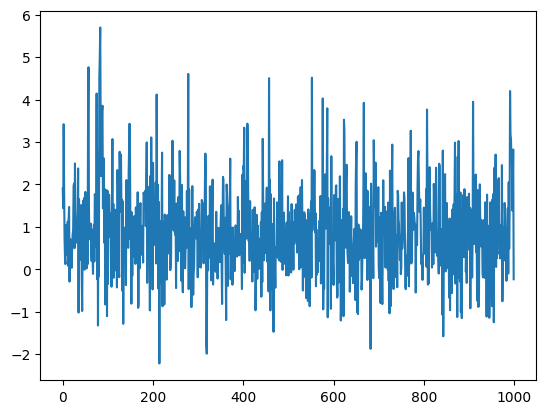

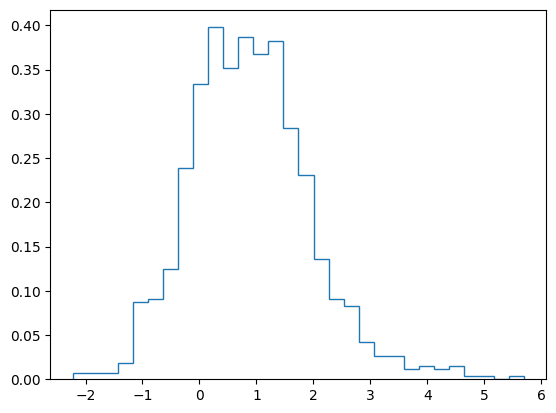

J0605+3757 A1


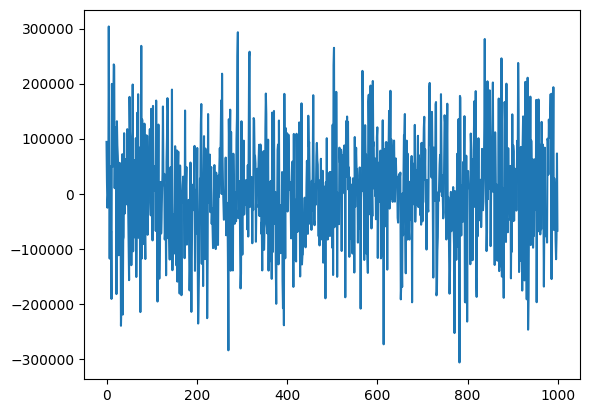

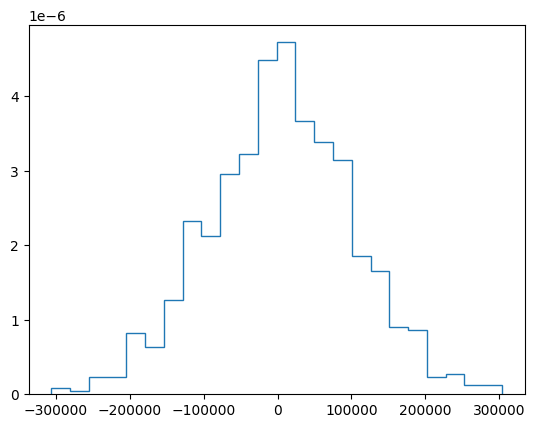

J0605+3757 ECC


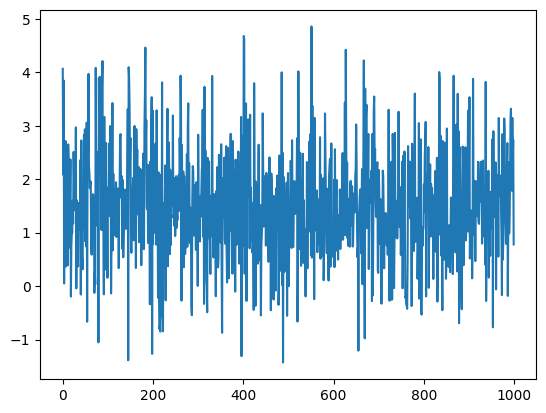

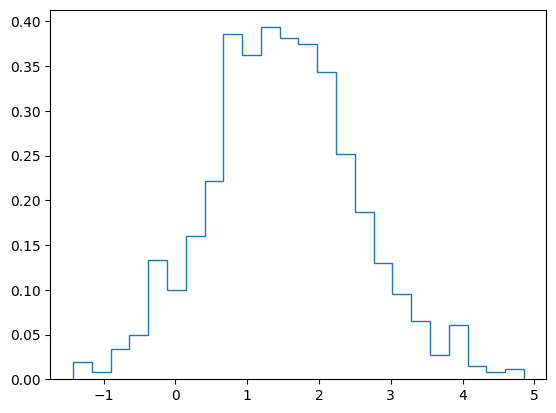

J0605+3757 OM


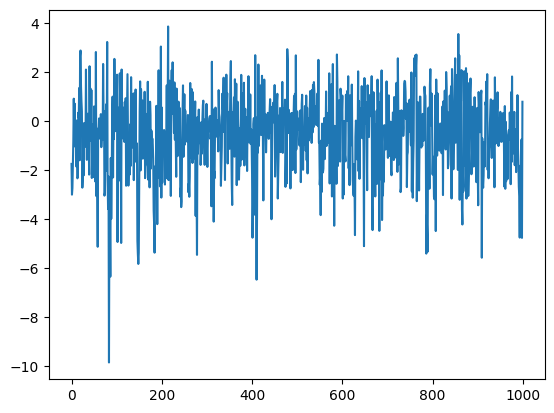

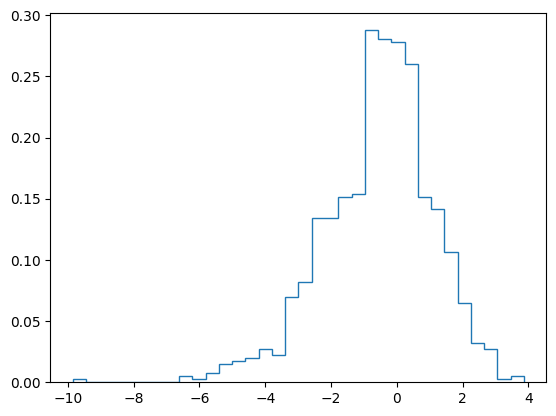

J0610-2100 PB


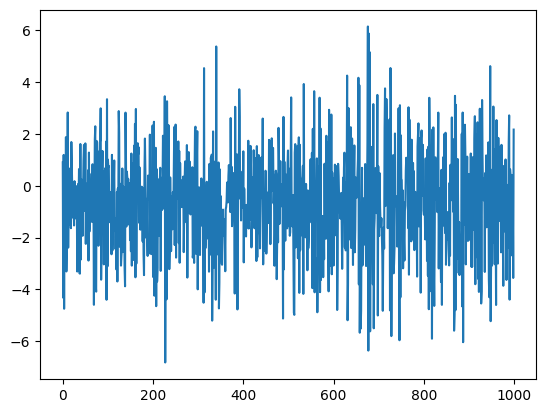

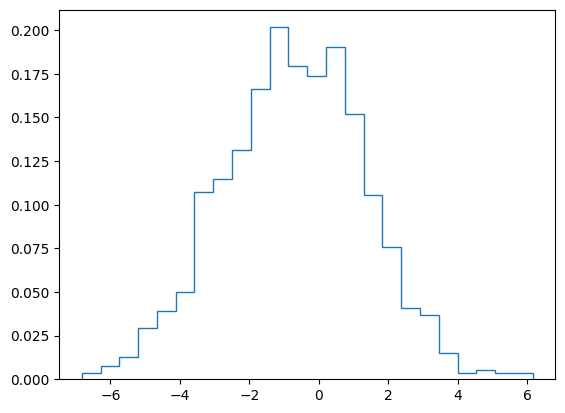

J0610-2100 A1


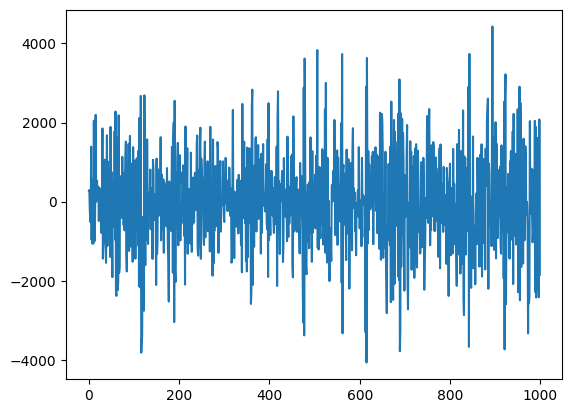

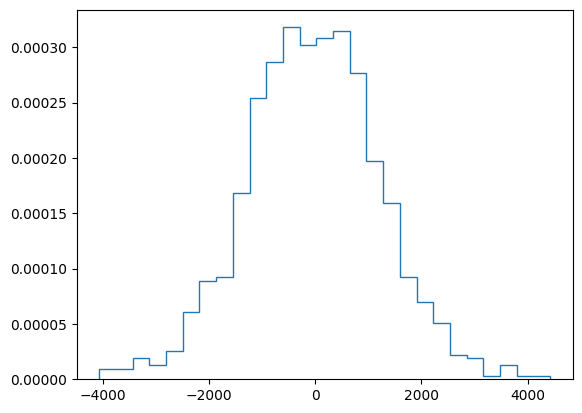

J0610-2100 EPS1


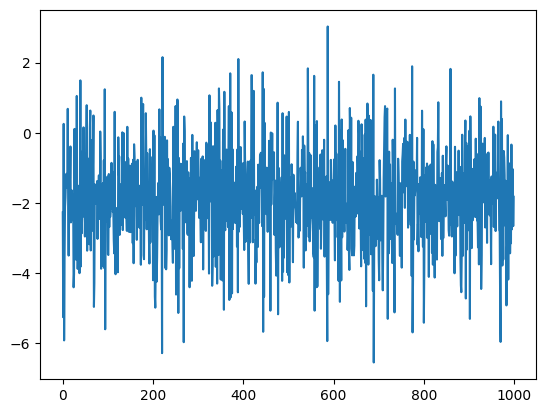

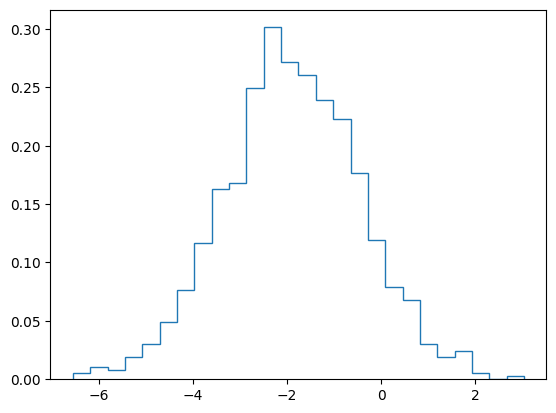

J0610-2100 EPS2


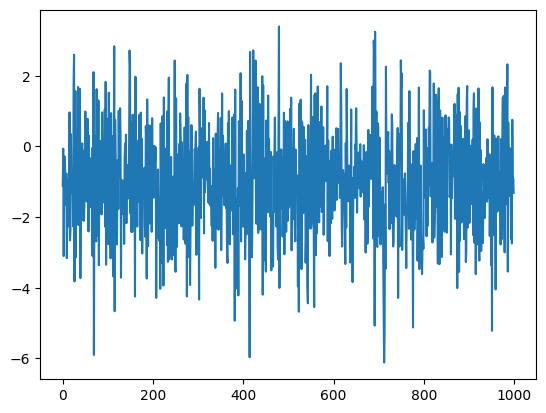

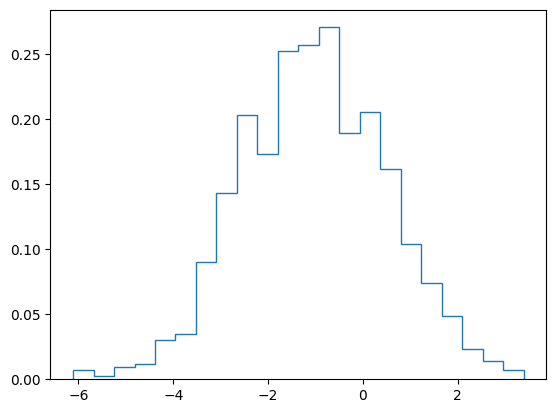

In [27]:
c = samples['z_b_J0605+3757']# * TM[0].sigma_b[None,:]# + TM[0].hat_b[None,:]
for i in range(c.shape[1]):
    print(TM[0].name, TM[0].Mb_labels[i])
    plt.plot(c[:,i])
    plt.show()

    plt.hist(c[:,i], bins='auto', density=True, histtype='step')
    plt.show()

c = samples['z_b_J0610-2100']# * TM[1].sigma_b[None,:]# + TM[1].hat_b[None,:]
for i in range(c.shape[1]):
    print(TM[1].name, TM[1].Mb_labels[i])
    plt.plot(c[:,i])
    plt.show()

    plt.hist(c[:,i], bins='auto', density=True, histtype='step')
    plt.show()


J0605+3757_Rcvr1_2_GUPPI_efac


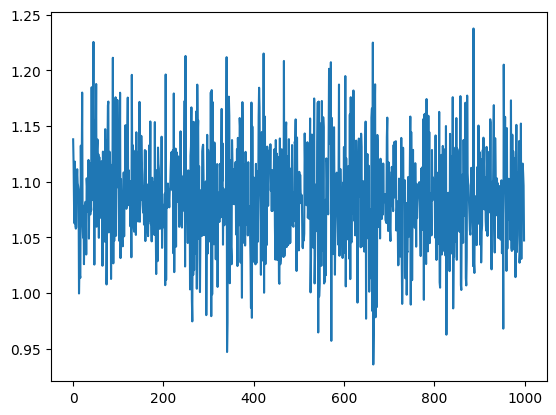

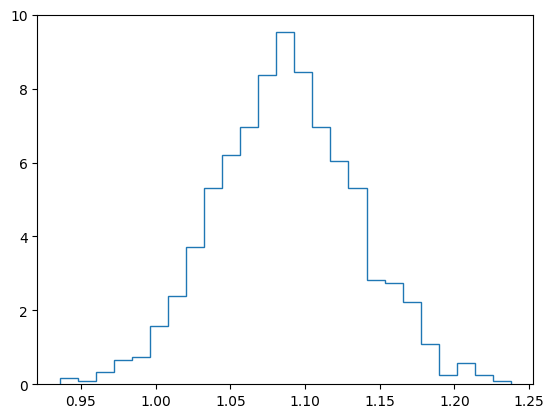

J0605+3757_Rcvr_800_GUPPI_efac


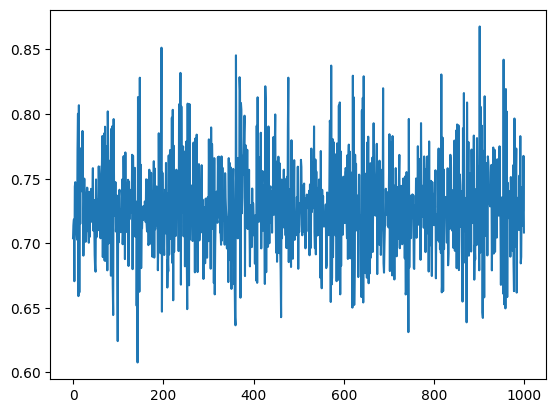

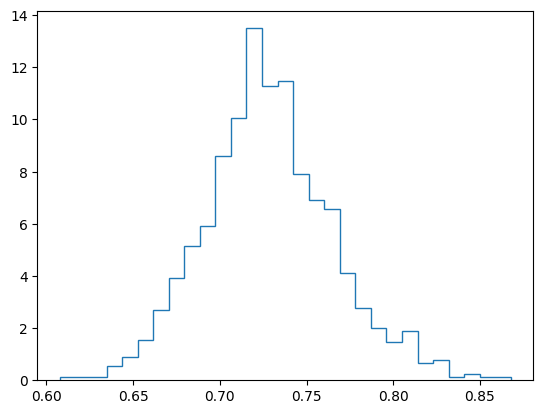

J0605+3757_Rcvr1_2_GUPPI_log10_t2equad


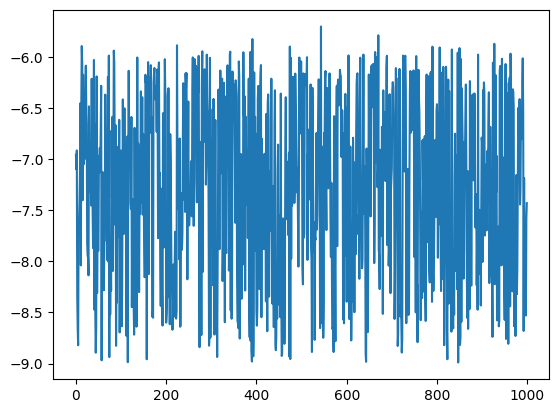

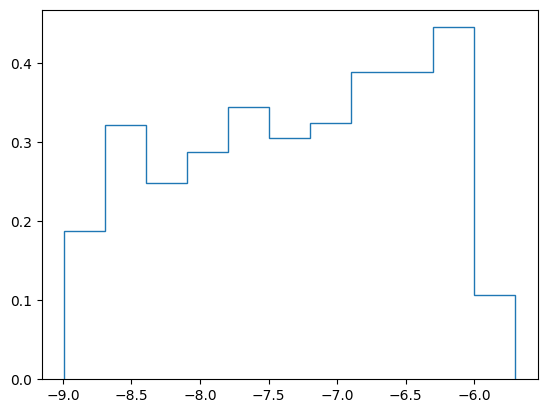

J0605+3757_Rcvr_800_GUPPI_log10_t2equad


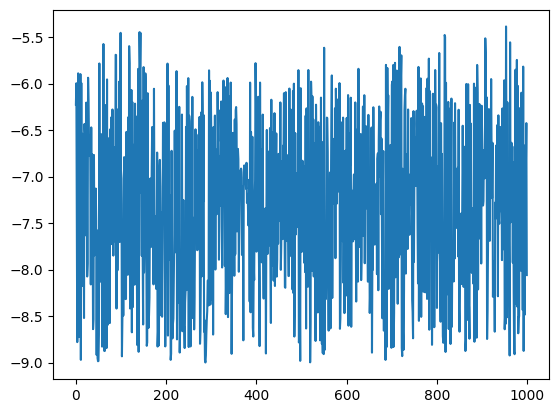

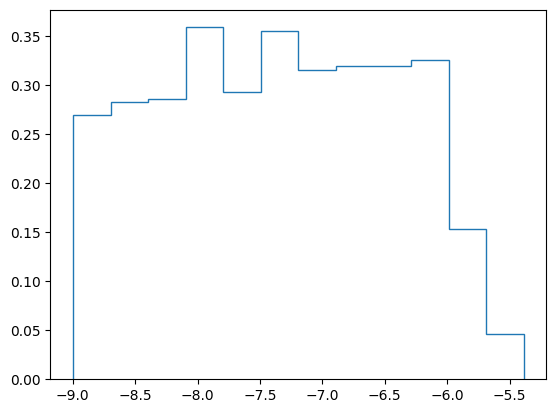

J0605+3757_Rcvr1_2_GUPPI_log10_ecorr


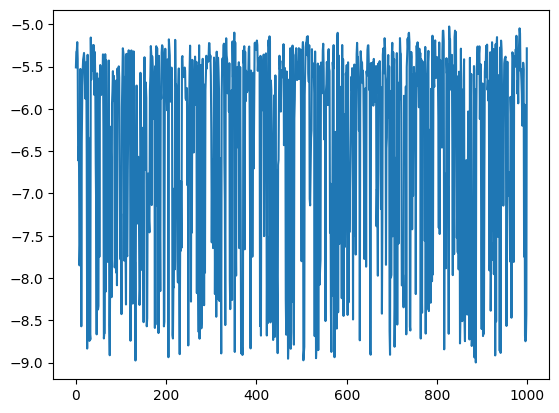

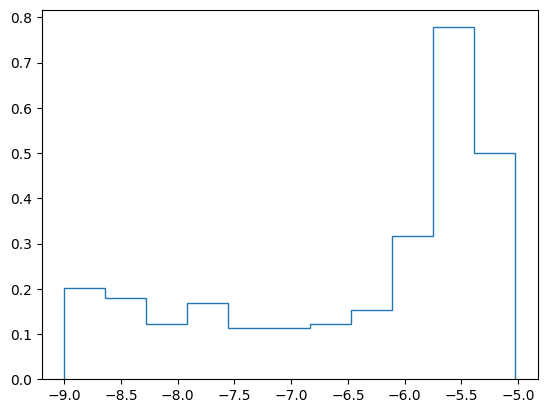

In [6]:
for i in range(5):
    print(f'{wn_model.get_param_names()[i]}')
    c = samples['theta_wn'][:, i]

    plt.plot(c)
    plt.show()
    plt.hist(c, bins='auto', density=True, histtype='step')
    plt.show()

In [3]:
binary_params = ['PB', 'PBDOT', 'A1', 'A1DOT', 'T0', 'TASC', 'ECC', 'EDOT', 'OM', 'OMDOT', 
                 'EPS1', 'EPS2', 'SINI', 'M2', 'KIN', 'KOM', 'H3', 
                 'FB0', 'FB1', 'FB2', 'FB3', 'FB4', 'FB5']

In [4]:
M_full = [p.Mmat for p in psrs]
M_full_labels = [np.array(p.Mmat_labels) for p in psrs]

is_binary = []
for M in M_full_labels:
    b = jnp.array([(l in binary_params) for l in M])
    is_binary.append(b)

M_other = [M[:,~b] for M, b in zip(M_full, is_binary)]
U_other = [_timing_model_svd(M) for M in M_other]
M_other_labels = [M[~b] for M, b in zip(M_full_labels, is_binary)]

M_binary = [M[:,b] for M, b in zip(M_full, is_binary)]
M_binary_labels = [M[b] for M, b in zip(M_full_labels, is_binary)]

# Add the U_re to data
data.add_timing_design_matrix(U_other)

## Separate binary parameters

In [3]:
from ATLAS.pulsar import load_pulsars
from ATLAS.data import PTA_Data

npsrs = 10

par = sorted(glob(sim_path+'/par/*.par'))[:npsrs]
tim = sorted(glob(sim_path+'/tim/*.tim'))[:npsrs]

psrs = load_pulsars(par, tim, use_enterprise=True)

data = PTA_Data(psrs, fixed_res = False, marg_timing = True, 
                diag_white_cov = False, linear_timing = True)


ModuleNotFoundError: No module named 'ATLAS'

## Timing model

Lets try taking out the binary columns, normalizing the non-binary columns and add only the non-binary columns back

In [6]:
binary_params = ['PB', 'PBDOT', 'A1', 'A1DOT', 'T0', 'TASC', 'ECC', 'EDOT', 'OM', 'OMDOT', 
                 'EPS1', 'EPS2', 'SINI', 'M2', 'KIN', 'KOM', 'H3', 
                 'FB0', 'FB1', 'FB2', 'FB3', 'FB4', 'FB5']

In [2]:
psrs[0]

NameError: name 'psrs' is not defined

In [ ]:
M_full = [p.Mmat for p in psrs]
M_full_labels = [np.array(p.Mmat_labels) for p in psrs]

is_binary = []
for M in M_full_labels:
    b = jnp.array([(l in binary_params) for l in M])
    is_binary.append(b)

M_other = [M[:,~b] for M, b in zip(M_full, is_binary)]
U_other = [_timing_model_svd(M) for M in M_other]
M_other_labels = [M[~b] for M, b in zip(M_full_labels, is_binary)]

M_binary = [M[:,b] for M, b in zip(M_full, is_binary)]
M_binary_labels = [M[b] for M, b in zip(M_full_labels, is_binary)]
hat_binary = []


# Add the U_other to data
data.add_timing_design_matrix(U_other)

In [ ]:

from ATLAS.psd_functions import powerlaw, free_spectrum, hd_orf
from ATLAS.signals.factorized.base import Red, SuperSignal
from ATLAS.signals.correlated.base import Correlated
from ATLAS.nMatrix.base import WhiteCov
from ATLAS.signals import signals_utils as sutils
import ATLAS.utils as atlas_utils
import ATLAS.signals.factorized.utils as unc_utils
import ATLAS.signals.correlated.utils as cor_utils

raw_res = jnp.concat(data.raw_residuals)

## White Noise Model
wn_model = WhiteCov(data = data, stabilize_TNT = True)
wn_lower_bound, wn_upper_bound = wn_model.get_prior_bounds() #white noise prior bounds
## Red Noise Model
non_gwb_nfreqs = 30
gwb_nfreqs = 14
sig_unc = Red(name='unc',
            psd_function = partial(powerlaw),
            nfreqs=non_gwb_nfreqs,
            lower_bound_psd = jnp.array([-18, 0.]),
            upper_bound_psd = jnp.array([-11, 7.0]),
            data = data,
            use_pulsar_tspan = False)
sig_cor = Correlated(name='cor',
            psd_function = partial(powerlaw),
            orf_function = hd_orf,
            nfreqs=gwb_nfreqs,
            lower_bound_psd = jnp.array([-18., 0.]),
            upper_bound_psd = jnp.array([-11., 1.]),
            data = data)
sig = SuperSignal(signal_list = [sig_unc],#, sig_cor],
                signal_combination_string = "ltm|unc->unc",
                data=data)


Construncting the white noise cov matrix for J0557+1551: 100%|██████████| 10/10 [00:02<00:00,  3.58it/s]


In [ ]:
import numpyro
import numpyro.distributions as dist
from numpyro.infer import MCMC, NUTS

from ATLAS.samplers.canetoadracing import MultiHMCGibbs

theta_wn_dist = dist.Uniform(wn_lower_bound, wn_upper_bound)
xs_dist = dist.Uniform(sig.model.lower_prior_lim_all, sig.model.upper_prior_lim_all)
z_a_dist = dist.Normal(0, 1).expand((sig.npsrs, sig.nmodes))
r_all = jnp.concatenate(data.raw_residuals)

def model():
    ######################################## White Noise ########################################
    # Declare the variables in the model
    theta_wn = numpyro.sample('theta_wn', theta_wn_dist)
    helpers_now = sig.get_helpers(reff = r_all, white_noise_params=theta_wn)
    
    ######################################## Red Noise ########################################
    # Declare the variables in the model
    xs = numpyro.sample('xs', xs_dist) #PSD params
    z_a = numpyro.sample('z_a', z_a_dist) #the reparam coefficients
    # evaluate the posterior
    lprob, coeff = sig.lnposterior_reparam(helpers = helpers_now, red_params = xs, z = z_a)
    numpyro.factor('lnpost', lprob + 0.5 * jnp.sum(z_a**2))
    numpyro.deterministic('coeff', coeff)


kernel = NUTS(model=model, max_tree_depth=8)

mcmc = MCMC(sampler=kernel, num_warmup=500, num_samples=2000)

mcmc.run(jrandom.key(170817))
samples = mcmc.get_samples()

  0%|          | 0/2500 [00:18<?, ?it/s]/home/kyleg/miniforge3/envs/atlas/lib/python3.12/site-packages/jax/_src/compiler.py:833: UserWarning: Error writing persistent compilation cache entry for 'jit__body_fn': JaxRuntimeError: RESOURCE_EXHAUSTED: Failed to serialize message of type xla.gpu.GpuExecutableProto because its size must be smaller than 2GiB: 3424249175; at byte 0; at uncompressed byte 0; at byte 1653452748
  warnings.warn(
warmup:   1%|          | 23/2500 [02:11<6:06:41,  8.88s/it, 6 steps of size 1.73e-03. acc. prob=0.67]  

### Other stuff I tried

In [10]:
# Custom timing model: Split the timing model matrix into binary and non-binary
# r = dt - Me_{non-binary} - Me_{binary}
binary_priors = {
    'PB':       dist.Uniform(0.05, 500),        # Orbital period (days)
    'PBDOT':    dist.Uniform(-1e-10, 1e-10),    # Time derivative of orbital period
    'A1':       dist.Uniform(0, 150),           # Projected semi-major axis (light-seconds)
    'A1DOT':    dist.Uniform(-1e-10, 1e-10),    # Time derivative of A1
#    '_DT0':     dist.Uniform(-1, 1),            # delta of T0 (MJD) 
#    'T0':       None, # Use _DT0 to derive      # Epoch of periastron passage (MJD)
#    '_DTASC':   dist.Uniform(-1, 1),            # delta of TASC (MJD)
#    'TASC':     None, # Use _DTASC to derive    # Epoch of ascending node passage (MJD)
    'ECC':      dist.Uniform(0, 1),             # Orbital eccentricity
    'EDOT':     dist.Uniform(-1e-10, 0),        # Time derivative of eccentricity
    'OM':       dist.Uniform(-360, 360),        # Longitude of periastron (deg)
    'OMDOT':    dist.Uniform(-3, 3),            # Time derivative of OM
    'EPS1':     dist.Uniform(-1, 1),            # Laplace-Lagrange parameter e*sin(omega)
    'EPS2':     dist.Uniform(-1, 1),            # Laplace-Lagrange parameter e*cos(omega)
    '_COSI':    dist.Uniform(0, 1),             # cos(inclination) [Used to derive SINI]
    'SINI':     None, # Use _COSI to derive     # sin(inclination)
    'M2':       dist.TruncatedNormal( loc=0.214, scale=0.25, 
                low=0, high=1),                 # Companion mass (solar masses)
    'KIN':      dist.Uniform(0, 360),           # Inclination angle (deg), used by DDK
    'KOM':      dist.Uniform(-180, 180),        # Longitude of ascending node (deg), used by DDK
    'H3':       dist.Uniform(-1e-6, 1e-6),      # Orthometric Shapiro delay amplitude
    'FB0':      dist.Uniform(0, 1),             # Orbital frequency and derivatives (ELL1)
    'FB1':      dist.Uniform(-1e-15, 1e-15),     
    'FB2':      dist.Uniform(-1e-15, 1e-15),
    'FB3':      dist.Uniform(-1e-15, 1e-15),
    'FB4':      dist.Uniform(-1e-15, 1e-15),
    'FB5':      dist.Uniform(-1e-15, 1e-15),
}

class psr_timingmodel:
    def __init__(self, psr, inflate_z=1e5):
        self.psr = psr
        self.name = psr.name
        self.residuals = psr.residuals
        self.M = psr.Mmat # (n_toas, npar)
        self.M_labels = psr.Mmat_labels # Labels of the columns in the M matrix (npar,)
        self.M_par = self.M.shape[1] # number of parameters in the M matrix
        self.U = _timing_model_svd(self.M) # Use TM svd

        # Fit parameter values and uncertainties with an added offset column
        self.hat = jnp.insert(psr.fit_param_values, 0, 0) # Add offset column (npar,)
        self.sigma = jnp.insert(psr.fit_param_uncertainties, 0, 1) # Add offset column (npar,)
        self.inflate_z = inflate_z # How much to scale the prior on the sigma

        # Make boolean masks of binary and other parameters in the M matrix
        self.Mb_idx = jnp.array([label in binary_priors for label in self.M_labels])
        self.Mo_idx = ~self.Mb_idx

        self.Mb = self.M[:, self.Mb_idx] # Binary parameters in the M matrix
        self.Mb_labels = [label for label in self.M_labels if label in binary_priors] # Labels of the binary parameters in the M matrix
        self.Mb_par = self.Mb.shape[1] # number of binary parameters in the M matrix
        self.Ub = self.U[:, self.Mb_idx] # SVD of binary parameters in the M matrix

        self.Mo = self.M[:, self.Mo_idx] # Other parameters in the M matrix
        self.Mo_labels = [label for label in self.M_labels if label not in binary_priors] # Labels of the other parameters in the M matrix
        self.Mo_par = self.Mo.shape[1] # number of other parameters in the M matrix
        self.Uo = self.U[:, self.Mo_idx] # SVD of other parameters in the M matrix

    def sample_prior(self):
        z_dist = dist.Normal(0, self.inflate_z).expand((self.M_par,))
        z = numpyro.sample(f'z_tm_{self.name}', z_dist)
        # Convert to epsilon
        epsilon = z*self.sigma
        return epsilon

    def compute_r(self, epsilon, use_svd=False):
        # Given epsilons, just multiply by the M matrix to get the timing residuals
        if use_svd:
            return self.residuals - self.U @ epsilon
        else:
            return self.residuals - self.M @ epsilon

    def init_params(self):
        x0 = {f'z_tm_{self.name}': jnp.zeros(self.M_par)}
        return x0

    def sample_prior_split(self):
        # Non-binary parameters first
        z_dist = dist.Normal(0, self.inflate_z).expand((self.Mo_par,))
        z = numpyro.sample(f'z_tm_mo_{self.name}', z_dist)
        epsilon_o = z*self.sigma[self.Mo_idx]

        # Binary parameters next
        epsilon_b = jnp.zeros(self.Mb_par) # Initialize binary parameter epsilons
        for i, label in enumerate(self.Mb_labels):
            # Most parameters have defined priors except for SINI
            if 'SINI' in label:
                # Sample in uniform COSI instead
                cosi_dist = dist.Uniform(0, 1)
                cosi = numpyro.sample(f'{self.name}_COSI', cosi_dist)
                v = jnp.sqrt(1 - cosi**2)
                numpyro.deterministic(f'{self.name}_SINI', v)
                dv = v - self.hat[self.Mb_idx][i]
                epsilon_b = epsilon_b.at[i].set(dv)
            else:
                # For other binary parameters, just use the prior
                prior_dist = binary_priors[label]
                v = numpyro.sample(f'{self.name}_{label}', prior_dist)
                dv = v - self.hat[self.Mb_idx][i]
                epsilon_b = epsilon_b.at[i].set(dv)

        return epsilon_o, epsilon_b

    def compute_r_split(self, epsilon_o, epsilon_b, use_svd=False):
        if use_svd:
            r = self.residuals - self.Uo @ epsilon_o - self.Mb @ epsilon_b
        else:
            r = self.residuals - self.Mo @ epsilon_o - self.Mb @ epsilon_b
        return r

    def init_params_split(self):
        x0 = {f'z_tm_mo_{self.name}': jnp.zeros(self.Mo_par)}
        for label in self.Mb_labels:
            x0[f'{self.name}_{label}'] = 0.0
        return x0

TM = [psr_timingmodel(p, inflate_z=1e5) for p in psrs]


In [48]:
epsilon = [jnp.zeros(t.M_par) for t in TM]
r = jnp.concatenate([t.compute_r(e, use_svd=False) for t,e in zip(TM, epsilon)])
np.sum(r - raw_res)

NameError: name 'TM' is not defined

In [14]:
import numpyro
import numpyro.distributions as dist
from numpyro.infer import MCMC, NUTS

from ATLAS.samplers.canetoadracing import MultiHMCGibbs

theta_wn_dist = dist.Uniform(wn_lower_bound, wn_upper_bound)
xs_dist = dist.Uniform(sig.model.lower_prior_lim_all, sig.model.upper_prior_lim_all)
z_a_dist = dist.Normal(0, 1).expand((sig.npsrs, sig.nmodes))


def model():
    ######################################## Timing Model ########################################
    epsilon = [TM[i].sample_prior() for i in range(npsrs)]
    r_stoc = jnp.concatenate([TM[i].compute_r(epsilon[i], use_svd=False) for i in range(npsrs)])

    ######################################## White Noise ########################################
    # Declare the variables in the model
    theta_wn = numpyro.sample('theta_wn', theta_wn_dist)
    helpers_now = sig.get_helpers(reff = r_stoc, white_noise_params=theta_wn)
    
    ######################################## Red Noise ########################################
    # Declare the variables in the model
    xs = numpyro.sample('xs', xs_dist) #PSD params
    z_a = numpyro.sample('z_a', z_a_dist) #the reparam coefficients
    # evaluate the posterior
    lprob, coeff = sig.lnposterior_reparam(helpers = helpers_now, red_params = xs, z = z_a)
    numpyro.factor('lnpost', lprob + 0.5 * jnp.sum(z_a**2))
    numpyro.deterministic('coeff', coeff)

x0 = {
    'theta_wn': (wn_lower_bound + wn_upper_bound) / 2,
    'xs': (sig.model.lower_prior_lim_all + sig.model.upper_prior_lim_all) / 2,
    'z_a': jnp.zeros((sig.npsrs, sig.nmodes)),
}
[x0.update(TM[i].init_params()) for i in range(npsrs)]

kernel = NUTS(model=model, max_tree_depth=12)

mcmc = MCMC(sampler=kernel, num_warmup=500, num_samples=2000)

mcmc.run(jrandom.key(170817))
samples = mcmc.get_samples()

warmup:   7%|▋         | 171/2500 [01:27<19:51,  1.95it/s, 239 steps of size 1.98e-03. acc. prob=0.76]   


KeyboardInterrupt: 

In [1]:
plt.plot(samples['epsilon_o'][:,1]);

NameError: name 'plt' is not defined